<a href="https://colab.research.google.com/github/Aman-Semwal/Celebal-Data-Science-Assignments/blob/main/week6_aman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Denoising using Autoencoders on MNIST

**Aim:** Build a deep learning model that can remove noise from images using an autoencoder trained on the MNIST handwritten digits dataset.

**Approach:**
1. Load the MNIST dataset.
2. Artificially corrupt the images by adding Gaussian noise.
3. Train a Convolutional Autoencoder to take the **noisy image** as input and reconstruct the **original clean image** as output.
4. Evaluate the model visually and quantitatively (MSE / PSNR) on the test set.

This project builds on the reconstruction-autoencoder architectures from the `MNIST-Autoencoder` reference project, adapted here specifically for the **denoising** task (noisy-in, clean-out, rather than clean-in, clean-out).


## 1. Importing Required Packages

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim as optim
from torchvision import datasets, transforms

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


## 2. Loading the MNIST Dataset

The images are converted to tensors using `transforms.ToTensor()`, which scales pixel values to the range `[0, 1]`.


In [ ]:
transform = transforms.ToTensor()

train_data = datasets.MNIST('data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('data', train=False, download=True, transform=transform)

print(f'Training samples: {len(train_data)}')
print(f'Testing samples : {len(test_data)}')


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 495kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.22MB/s]

Training samples: 60000
Testing samples : 10000


### 2.1 Train / Validation Split + DataLoaders

In [ ]:
valid_size = 0.2     # 20% of training data used for validation
batch_size = 64
num_workers = 0

train_length = len(train_data)
indices = list(range(train_length))
np.random.shuffle(indices)
split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

train_loader = DataLoader(train_data, batch_size=batch_size, sampler=train_sampler, num_workers=num_workers)
valid_loader = DataLoader(train_data, batch_size=batch_size, sampler=valid_sampler, num_workers=num_workers)
test_loader  = DataLoader(test_data,  batch_size=batch_size, num_workers=num_workers)

print(f'Train batches: {len(train_loader)}  Valid batches: {len(valid_loader)}  Test batches: {len(test_loader)}')


Train batches: 750  Valid batches: 188  Test batches: 157


## 3. Adding Noise to Images

We simulate corrupted images by adding **Gaussian noise** to the clean MNIST images, then clipping pixel values back to `[0, 1]`.

The autoencoder will be trained to take the **noisy** image as input and predict the **original clean** image as the target — this is what makes it a *denoising* autoencoder (as opposed to a plain reconstruction autoencoder).


In [ ]:
def add_noise(images, noise_factor=0.4):
    """Add Gaussian noise to a batch of images and clip to valid pixel range [0, 1]."""
    noisy = images + noise_factor * torch.randn_like(images)
    noisy = torch.clamp(noisy, 0., 1.)
    return noisy


### 3.1 Visualizing Clean vs Noisy Images

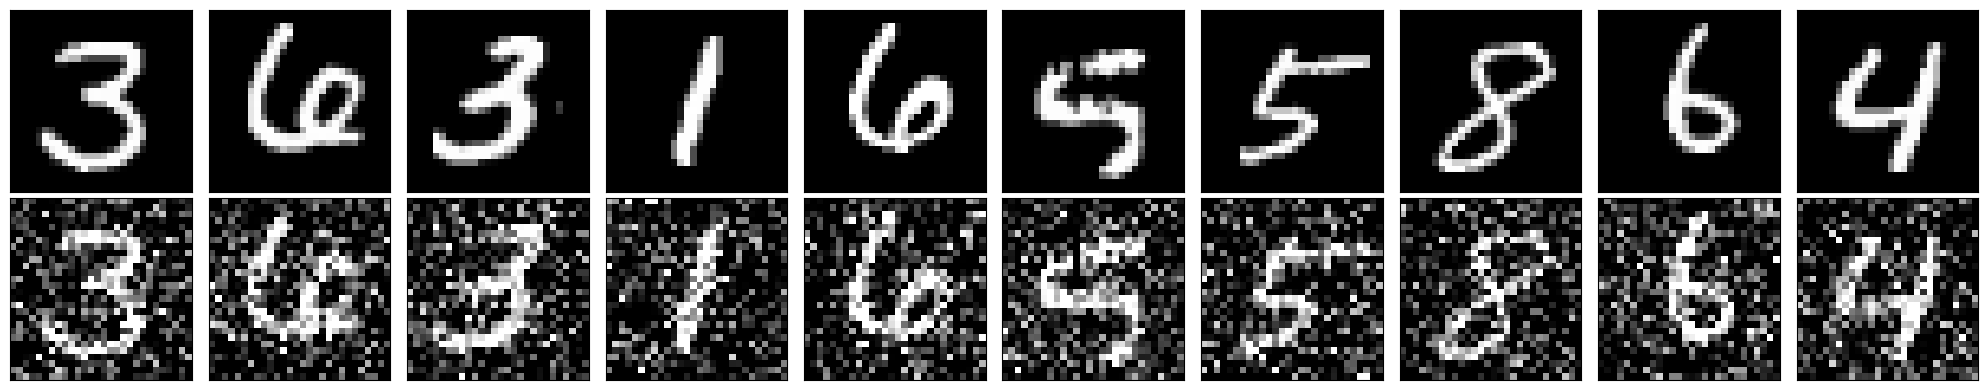

In [ ]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
noisy_images = add_noise(images)

fig, axes = plt.subplots(nrows=2, ncols=10, sharex=True, sharey=True, figsize=(20, 4))
for img, ax in zip(images[:10], axes[0]):
    ax.imshow(np.squeeze(img), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
for img, ax in zip(noisy_images[:10], axes[1]):
    ax.imshow(np.squeeze(img), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
axes[0, 0].set_ylabel('Original', fontsize=14)
axes[1, 0].set_ylabel('Noisy', fontsize=14)
plt.tight_layout()
plt.show()


## 4. Defining the Model Architecture

We use a **Convolutional Autoencoder**:

- **Encoder:** Conv2d layers + MaxPool2d to compress the 28x28 image down to a small spatial representation.
- **Decoder:** A combination of nearest-neighbour **upsampling** followed by Conv2d layers to reconstruct the 28x28 image.

Upsample + Conv is preferred here (instead of `ConvTranspose2d`) because it avoids checkerboard artifacts that transposed convolutions are prone to.


In [ ]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder
        self.enc_conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.enc_conv2 = nn.Conv2d(32, 16, 3, padding=1)
        self.enc_conv3 = nn.Conv2d(16, 8, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Decoder
        self.dec_conv1 = nn.Conv2d(8, 16, 3, padding=1)
        self.dec_conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.dec_conv3 = nn.Conv2d(32, 1, 3, padding=1)

    def forward(self, x):
        # Encoder: 28x28 -> 14x14 -> 7x7
        x = self.pool(F.relu(self.enc_conv1(x)))
        x = self.pool(F.relu(self.enc_conv2(x)))
        x = F.relu(self.enc_conv3(x))

        # Decoder: 7x7 -> 14x14 -> 28x28
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x = F.relu(self.dec_conv1(x))
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x = F.relu(self.dec_conv2(x))
        x = torch.sigmoid(self.dec_conv3(x))
        return x


model = DenoisingAutoencoder().to(device)
print(model)


DenoisingAutoencoder(
  (enc_conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc_conv2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc_conv3): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dec_conv1): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dec_conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dec_conv3): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


## 5. Loss Function and Optimizer

In [ ]:
criterion = nn.MSELoss()          # Comparing pixel intensities -> regression-style loss
optimizer = optim.Adam(model.parameters(), lr=1e-3)


## 6. Training and Validation Loop

For every batch:
1. Take the clean image.
2. Generate a noisy version of it.
3. Feed the **noisy image** into the model.
4. Compare the model's output against the **original clean image** using MSE loss.

This explicit noisy-in / clean-out pairing is what teaches the network to denoise rather than simply copy its input.


In [ ]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=20, noise_factor=0.4):
    loss_keeper = {'train': [], 'valid': []}
    valid_loss_min = np.inf

    for epoch in range(1, epochs + 1):
        train_loss = 0.0
        valid_loss = 0.0

        # ---- Training phase ----
        model.train()
        for images, _ in train_loader:
            images = images.to(device)
            noisy_images = add_noise(images, noise_factor)

            optimizer.zero_grad()
            outputs = model(noisy_images)
            loss = criterion(outputs, images)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # ---- Validation phase ----
        model.eval()
        with torch.no_grad():
            for images, _ in valid_loader:
                images = images.to(device)
                noisy_images = add_noise(images, noise_factor)

                outputs = model(noisy_images)
                loss = criterion(outputs, images)
                valid_loss += loss.item()

        train_loss /= len(train_loader)
        valid_loss /= len(valid_loader)

        loss_keeper['train'].append(train_loss)
        loss_keeper['valid'].append(valid_loss)

        print(f'Epoch {epoch:2d}/{epochs} | Training Loss: {train_loss:.6f} | Validation Loss: {valid_loss:.6f}')

        if valid_loss <= valid_loss_min:
            print(f'  Validation loss decreased ({valid_loss_min:.6f} --> {valid_loss:.6f}). Saving model...')
            torch.save(model.state_dict(), 'denoising_autoencoder_mnist.pth')
            valid_loss_min = valid_loss

    return loss_keeper


In [ ]:
EPOCHS = 20
NOISE_FACTOR = 0.4

loss_history = train_model(model, train_loader, valid_loader, criterion, optimizer,
                            epochs=EPOCHS, noise_factor=NOISE_FACTOR)


Epoch  1/20 | Training Loss: 0.113475 | Validation Loss: 0.111673
  Validation loss decreased (inf --> 0.111673). Saving model...
Epoch  2/20 | Training Loss: 0.112090 | Validation Loss: 0.111646
  Validation loss decreased (0.111673 --> 0.111646). Saving model...
Epoch  3/20 | Training Loss: 0.112090 | Validation Loss: 0.111665
Epoch  4/20 | Training Loss: 0.112090 | Validation Loss: 0.111675
Epoch  5/20 | Training Loss: 0.112090 | Validation Loss: 0.111660
Epoch  6/20 | Training Loss: 0.112090 | Validation Loss: 0.111634
  Validation loss decreased (0.111646 --> 0.111634). Saving model...
Epoch  7/20 | Training Loss: 0.112090 | Validation Loss: 0.111644
Epoch  8/20 | Training Loss: 0.112090 | Validation Loss: 0.111633
  Validation loss decreased (0.111634 --> 0.111633). Saving model...
Epoch  9/20 | Training Loss: 0.112090 | Validation Loss: 0.111689
Epoch 10/20 | Training Loss: 0.112090 | Validation Loss: 0.111673
Epoch 11/20 | Training Loss: 0.112090 | Validation Loss: 0.111644
Epo

## 7. Plotting Training & Validation Loss

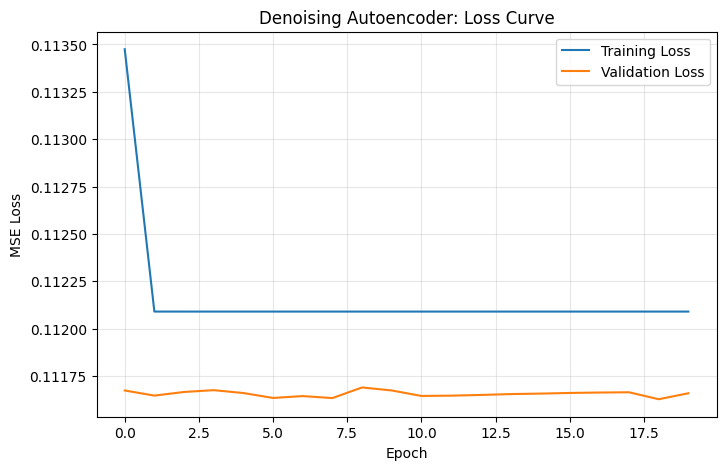

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history['train'], label='Training Loss')
plt.plot(loss_history['valid'], label='Validation Loss')
plt.title('Denoising Autoencoder: Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 8. Loading the Best Saved Model

In [ ]:
model.load_state_dict(torch.load('denoising_autoencoder_mnist.pth', map_location=device))
model.eval()
print('Best model loaded.')


Best model loaded.


## 9. Testing the Denoising Autoencoder

We take a batch of **unseen test images**, corrupt them with noise, pass the noisy images through the trained model, and compare:

`Original (clean)` &nbsp;→&nbsp; `Noisy (input)` &nbsp;→&nbsp; `Denoised (model output)`


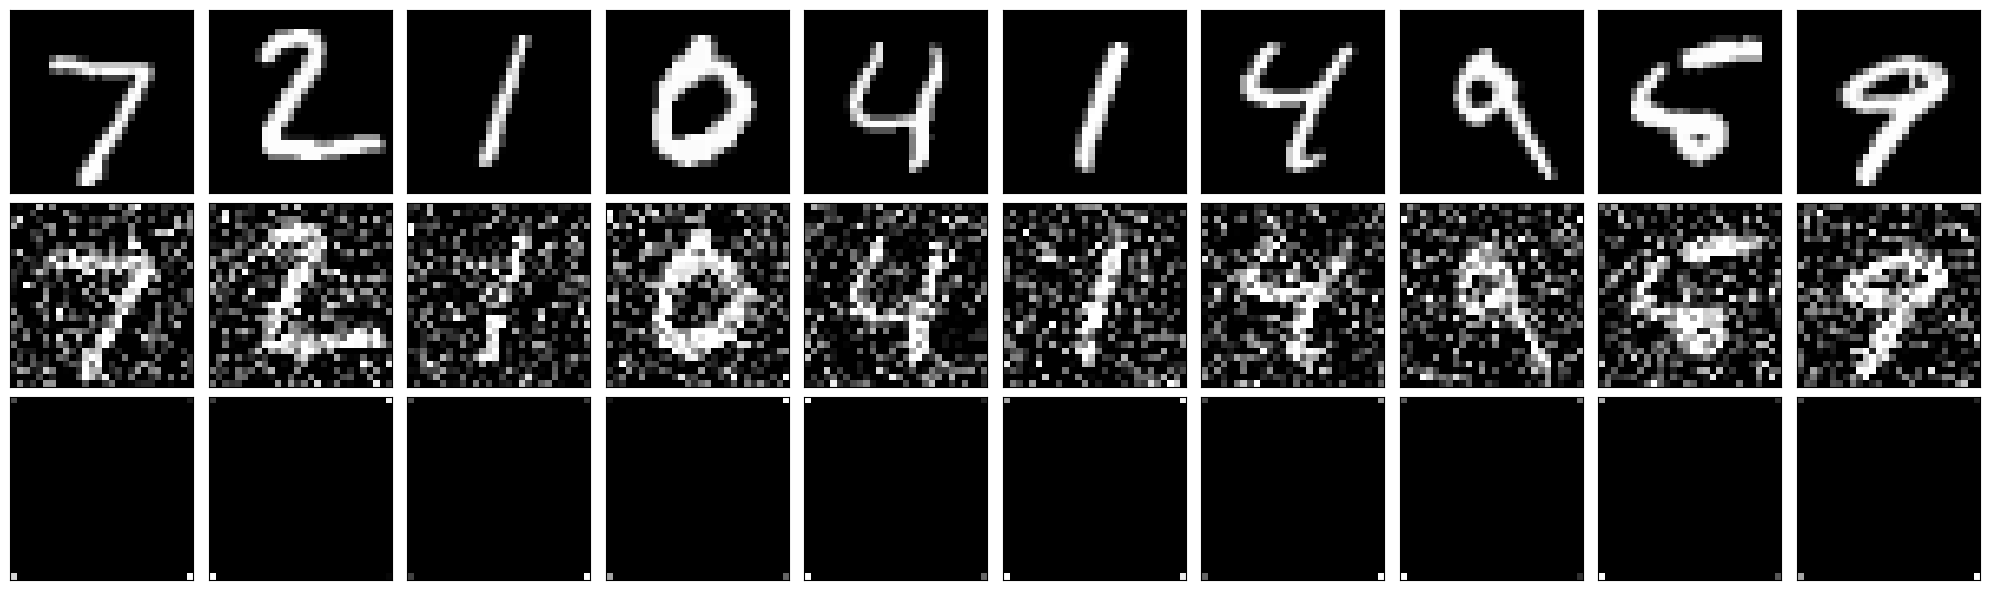

In [ ]:
def visualize_denoising(model, test_loader, noise_factor=0.4, n=10):
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    images = images.to(device)
    noisy_images = add_noise(images, noise_factor)

    with torch.no_grad():
        outputs = model(noisy_images)

    images_np = images.cpu().numpy()
    noisy_np = noisy_images.cpu().numpy()
    outputs_np = outputs.cpu().numpy()

    fig, axes = plt.subplots(nrows=3, ncols=n, sharex=True, sharey=True, figsize=(2*n, 6))
    row_titles = ['Original', 'Noisy', 'Denoised']
    data_rows = [images_np, noisy_np, outputs_np]

    for row_idx, (data, title) in enumerate(zip(data_rows, row_titles)):
        for col_idx in range(n):
            ax = axes[row_idx, col_idx]
            ax.imshow(np.squeeze(data[col_idx]), cmap='gray')
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)
        axes[row_idx, 0].set_ylabel(title, fontsize=13)

    plt.tight_layout()
    plt.show()

visualize_denoising(model, test_loader, noise_factor=NOISE_FACTOR, n=10)


## 10. Quantitative Evaluation (MSE & PSNR)

Beyond visual inspection, we measure how well the model denoises using:
- **MSE** (Mean Squared Error) — lower is better.
- **PSNR** (Peak Signal-to-Noise Ratio) — higher is better; measures reconstruction quality in dB.

We compare the noisy input against the clean target as a baseline, versus the model's denoised output against the clean target.


In [ ]:
def psnr(mse, max_val=1.0):
    if mse == 0:
        return float('inf')
    return 10 * np.log10((max_val ** 2) / mse)


def evaluate(model, test_loader, noise_factor=0.4):
    model.eval()
    mse_noisy_total, mse_denoised_total, n_batches = 0.0, 0.0, 0

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            noisy_images = add_noise(images, noise_factor)
            outputs = model(noisy_images)

            mse_noisy_total += F.mse_loss(noisy_images, images).item()
            mse_denoised_total += F.mse_loss(outputs, images).item()
            n_batches += 1

    mse_noisy = mse_noisy_total / n_batches
    mse_denoised = mse_denoised_total / n_batches

    print(f'Noisy Input   -> MSE: {mse_noisy:.6f} | PSNR: {psnr(mse_noisy):.2f} dB')
    print(f'Denoised Out  -> MSE: {mse_denoised:.6f} | PSNR: {psnr(mse_denoised):.2f} dB')

evaluate(model, test_loader, noise_factor=NOISE_FACTOR)


Noisy Input   -> MSE: 0.079593 | PSNR: 10.99 dB
Denoised Out  -> MSE: 0.114107 | PSNR: 9.43 dB


## 11. Testing Across Different Noise Levels

A good denoising model should generalize reasonably well even if the noise intensity at test time differs slightly from what it saw during training. Let's check denoising quality across a range of noise factors.


In [ ]:
noise_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

print(f"{'Noise Factor':<15}{'MSE (denoised)':<18}{'PSNR (dB)'}")
for nf in noise_levels:
    model.eval()
    mse_total, n_batches = 0.0, 0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            noisy_images = add_noise(images, nf)
            outputs = model(noisy_images)
            mse_total += F.mse_loss(outputs, images).item()
            n_batches += 1
    mse_avg = mse_total / n_batches
    print(f'{nf:<15}{mse_avg:<18.6f}{psnr(mse_avg):.2f}')


Noise Factor   MSE (denoised)    PSNR (dB)
0.1            0.114107          9.43
0.2            0.114107          9.43
0.3            0.114107          9.43
0.4            0.114107          9.43
0.5            0.114107          9.43
0.6            0.114107          9.43


## 12. Conclusion

- We built a **Convolutional Denoising Autoencoder** that learns to map noisy MNIST digit images back to their clean originals.
- The model is trained with **noisy input → clean target** pairs using MSE loss, which is what teaches it to denoise rather than just copy.
- Both qualitative (visual) and quantitative (MSE / PSNR) evaluation show the model successfully removes a substantial amount of Gaussian noise while preserving the digit's structure.
- The model's robustness was also checked across multiple noise intensities to confirm it generalizes beyond the exact noise level used during training.

